# 🚀 TorchMPC + Learned Dynamics (OneStepMLP) for B747 — Tracking Step on θ

This notebook demonstrates an end-to-end control pipeline for `LinearLongitudinalB747-v0`:

1. **Create the B747 environment** and set the reference signal as a **step in θ (pitch)**.
2. **Collect a transition dataset** \((x_t, u_t) \to x_{t+1}\) using `TorchMPCAgent.collect_data(exploration="signals")`.
3. **Train the dynamics model** (OneStepMLP) within `TorchMPCAgent.train_dynamics()`.
4. **Perform an MPC rollout** via `agent.select_action()`.
5. **Evaluate quality** (overshoot / settling / SSE / smoothness) and via `ControlBenchmark`.

> **Units of measurement (important):** the B747 environment expects **actions in degrees**, while the internal linear model operates in **radians**. Inside `TorchMPCAgent` we work in **radians** and convert to **degrees** for `env.step()` via adapters.

> If old outputs without code remain in the notebook, simply do **Kernel -> Restart & Run All**.


In [1]:
# 📚 Импорт библиотек

import numpy as np
import gymnasium as gym
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from tensoraerospace.signals.standart import unit_step
from tensoraerospace.agent.mpc import (
    MPCAgent,
    MPCConstraints,
    MPCStepResponseExtraCostConfig,
    MPCTrackingExtraCostConfig,
    MPCWeights,
)
from tensoraerospace.benchmark import ControlBenchmark
from tensoraerospace.benchmark.function import find_step_function


2026-01-21 15:22:22.202299: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-21 15:22:22.345917: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-21 15:22:22.345952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-21 15:22:22.368956: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-21 15:22:22.433939: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# ⚙️ Конфигурация

np.random.seed(0)
torch.manual_seed(0)

# Симуляция
DT = 0.1
TN = 20.0
N_STEPS = int(TN / DT) + 1
T = np.arange(N_STEPS, dtype=np.float32) * DT

# Ступенчатый референс theta
REF_STEP_DEG = 1.0
REF_STEP_TIME_S = 5.0

# Сбор датасета (исследовательское управление)
# Чем больше эпизодов — тем шире покрытие пространства состояний (но дольше сбор/обучение).
COLLECT_EPISODES = 1500

# Амплитуда исследовательского управления (в единицах среды: deg для LinearLongitudinalB747)
ACTION_RANGE_DEG = 25.0

# Обучение dynamics
EPOCHS = 280
BATCH_SIZE = 1024
LR = 1e-5
HIDDEN = 256

# MPC
# (HORIZON * MPC_ITERS) напрямую влияет на скорость rollout.
HORIZON = 30
MPC_ITERS = 100
MPC_LR = 0.02

# MPC speed knobs
MPC_TRACK_BEST = True
MPC_BEST_CHECK_EVERY = 5
MPC_COMPILE_DYNAMICS = True  # включаем только на CUDA (см. agent init)
MPC_COMPILE_MODE = "reduce-overhead"

# Лимит скорости руля (deg/step)
DU_MAX_DEG = 10.0

# Веса MPC (в единицах модели: u,w [м/с], q,theta [рад])
W_U = 0.0
W_W = 0.0
W_Q = 0.2
W_THETA = 2000.0
W_ACTION = 0.01
W_DU = 5.0
TERMINAL_WEIGHT = 10.0

# --- step_response penalties (как в ImprovedB747Env) ---
OVERSHOOT_LIMIT_DEG = 0.05
SETTLE_BAND_DEG = 0.10
SETTLE_TIME_TARGET_S = 1.0

REF_CHANGE_THRESHOLD_DEG = 0.10
MIN_STEP_AMP_DEG = 0.50
Q_SETTLE_DEG_S = 0.25

W_OVERSHOOT = 8_000.0
W_TIME = 800.0
W_SETTLE = 8_000.0
W_SSE_STEADY = 40_000.0
W_OSC = 500.0
W_JERK = 50.0

W_DU_STEADY = 80.0
W_JERK_STEADY = 800.0

print("DT=", DT, "TN=", TN, "N_STEPS=", N_STEPS)


DT= 0.1 TN= 20.0 N_STEPS= 201


In [3]:
# 🛩️ Среда B747 + опорный сигнал (ступенька)

reference_signal = unit_step(
    tp=T,
    degree=float(REF_STEP_DEG),
    time_step=float(REF_STEP_TIME_S),
    output_rad=True,
).reshape(1, -1)

env = gym.make(
    "LinearLongitudinalB747-v0",
    number_time_steps=N_STEPS,
    initial_state=np.array([[0.0], [0.0], [0.0], [0.0]], dtype=np.float32),
    reference_signal=reference_signal,
    dt=float(DT),
)


In [4]:
# 📦 Инициализация TorchMPCAgent + сбор датасета в стиле DSAC

# Для B747:
# - внутреннее состояние берём из `env.unwrapped.model.xt` (радианы)
# - `env.step()` принимает действие в градусах
# - внутри MPC/модели используем радианы


def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


# DEVICE = pick_device()
DEVICE = 'cpu'
print("DEVICE:", DEVICE)


def obs_to_state(env, obs) -> np.ndarray:
    _ = obs
    return np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)


def action_from_env(a_env_deg: np.ndarray) -> np.ndarray:
    a_env_deg = np.asarray(a_env_deg, dtype=np.float32).reshape(-1)
    return np.deg2rad(a_env_deg).astype(np.float32)


def action_to_env(u_rad: np.ndarray) -> np.ndarray:
    u_rad = np.asarray(u_rad, dtype=np.float32).reshape(-1)
    return np.rad2deg(u_rad).astype(np.float32)


# Ограничения MPC в радианах (внутренние единицы модели)
_env_u_max_deg = float(np.asarray(env.action_space.high).reshape(-1)[0])
u_lim = float(np.deg2rad(_env_u_max_deg))
du_max = float(np.deg2rad(float(DU_MAX_DEG)))

weights = MPCWeights(
    Q_diag=np.array([W_U, W_W, W_Q, W_THETA], dtype=np.float32),
    R_diag=np.array([W_ACTION], dtype=np.float32),
    S_diag=np.array([W_DU], dtype=np.float32),
    terminal_weight=float(TERMINAL_WEIGHT),
)
constraints = MPCConstraints(
    u_min=np.array([-u_lim], dtype=np.float32),
    u_max=np.array([u_lim], dtype=np.float32),
    du_min=np.array([-du_max], dtype=np.float32),
    du_max=np.array([du_max], dtype=np.float32),
)

MAX_STEPS_COLLECT = int(env.unwrapped.number_time_steps - 2)
MEMORY_CAPACITY = int(COLLECT_EPISODES * MAX_STEPS_COLLECT + 1000)

SIGNAL_KINDS = [
    "random_steps",
    "unit_step",
    "multi_step",
    "ramp",
    "sinusoid",
    "multisine",
    "chirp",
    "square_wave",
    "triangular_wave",
    "sawtooth",
    "doublet",
    "pulse",
    "gaussian_pulse",
    "exponential",
    "damped_sinusoid",
]

# Тип отслеживания:
# - "step_response": step-response cost (overshoot/settling/osc/jerk)
# - "tracking": мягкое сглаживание управления (Δu, Δ²u)
TRACKING_TYPE = "step_response"

tracking_cfg = MPCTrackingExtraCostConfig(
    w_du=0.0,
    w_jerk=0.0,
)

step_cfg = MPCStepResponseExtraCostConfig.from_degrees(
    tracked_idx=3,  # theta
    rate_idx=2,  # q
    dt=float(DT),
    ref_change_threshold_deg=float(REF_CHANGE_THRESHOLD_DEG),
    min_step_amp_deg=float(MIN_STEP_AMP_DEG),
    overshoot_limit_deg=float(OVERSHOOT_LIMIT_DEG),
    settle_band_deg=float(SETTLE_BAND_DEG),
    settle_time_target_s=float(SETTLE_TIME_TARGET_S),
    rate_settle_deg_s=float(Q_SETTLE_DEG_S),
    w_overshoot=float(W_OVERSHOOT),
    w_time=float(W_TIME),
    w_settle=float(W_SETTLE),
    w_sse_steady=float(W_SSE_STEADY),
    w_osc=float(W_OSC),
    w_jerk=float(W_JERK),
    w_du_steady=float(W_DU_STEADY),
    w_jerk_steady=float(W_JERK_STEADY),
)

agent = MPCAgent(
    env,
    state_dim=4,
    action_dim=1,
    horizon=int(HORIZON),
    weights=weights,
    constraints=constraints,
    tracking_type=TRACKING_TYPE,
    tracking_config=tracking_cfg,
    step_response_config=step_cfg,
    extra_cost_fn=None,  # если задать функцию сюда — она переопределит режим
    iters=int(MPC_ITERS),
    mpc_lr=float(MPC_LR),
    mpc_optimizer="adam",
    warm_start=True,
    mpc_track_best=bool(MPC_TRACK_BEST),
    mpc_best_check_every=int(MPC_BEST_CHECK_EVERY),
    mpc_compile_dynamics=bool(MPC_COMPILE_DYNAMICS and DEVICE == "cuda"),
    mpc_compile_mode=str(MPC_COMPILE_MODE),
    model=None,  # OneStepMLP создастся внутри агента
    model_predict_delta=True,  # учим Δx (обычно устойчивее)
    hidden_layers=(int(HIDDEN), int(HIDDEN)),
    activation="relu",
    normalize=True,
    dynamics_lr=float(LR),
    memory_capacity=int(MEMORY_CAPACITY),
    obs_to_state=obs_to_state,
    action_to_env=action_to_env,
    action_from_env=action_from_env,
    device=DEVICE,
    seed=0,
)

print(
    "u_lim(deg)=",
    float(np.rad2deg(u_lim)),
    "du_max(deg/step)=",
    float(DU_MAX_DEG),
)

# Приводим ACTION_RANGE_DEG к доле от границ action_space (в единицах env)
_env_u_max = float(_env_u_max_deg)
action_amp_frac = float(
    np.clip(float(ACTION_RANGE_DEG) / max(1e-6, _env_u_max), 1e-3, 1.0)
)
print("action_amp_frac:", action_amp_frac)

print("Collecting transitions (signals)...")
agent.collect_data(
    num_episodes=int(COLLECT_EPISODES),
    max_steps=int(MAX_STEPS_COLLECT),
    exploration="signals",
    signal_kinds=SIGNAL_KINDS,
    dt=float(DT),
    action_amplitude_frac=action_amp_frac,
)

print("Replay size:", len(agent.memory))


DEVICE: cpu
u_lim(deg)= 25.0 du_max(deg/step)= 10.0
action_amp_frac: 1.0


Collect episodes:   0%|          | 0/1500 [00:00<?, ?it/s]/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
Collect episodes: 100%|██████████| 1500/1500 [00:09<00:00, 156.81it/s]

Replay size: 297000


In [16]:
# 🧠 Обучение dynamics внутри TorchMPCAgent
BATCH_SIZE=2048
metrics = agent.train_dynamics(
    epochs=int(EPOCHS),
    batch_size=int(BATCH_SIZE),
    loss="mse",
)

print("train metrics:", metrics)

# Быстрый sanity-check 1-step предсказания
s, a, _r, ns, _d = agent.memory.sample(batch_size=1)

s_t = torch.as_tensor(s, dtype=torch.float32, device=agent.device).view(1, -1)
a_t = torch.as_tensor(a, dtype=torch.float32, device=agent.device).view(1, -1)

with torch.no_grad():
    ns_pred = agent.mpc.dynamics(s_t, a_t)

print("x:", s.reshape(-1))
print("u(rad):", a.reshape(-1))
print("x_next true:", ns.reshape(-1))
print("x_next pred:", ns_pred.detach().cpu().numpy().reshape(-1))

Train dynamics: 100%|██████████| 40600/40600 [06:34<00:00, 102.93step/s, loss=2.62e-6]

train metrics: {'loss': 2.6240589948814578e-06}
x: [ 1.2137213   1.0791497   0.00625715 -0.01040315]
u(rad): [0.00243514]
x_next true: [ 1.2243578   1.168706    0.00539202 -0.00982075]
x_next pred: [ 1.2242687   1.1695724   0.00539431 -0.00981938]


In [17]:
agent.to_device("cpu")
print("MPC device:", agent.device)


MPC device: cpu


In [18]:
# 🎛️ Tracking mode внутри TorchMPCAgent

# Для rollout (baseline/target) нужен порог в радианах
ref_change_threshold_rad = float(np.deg2rad(float(REF_CHANGE_THRESHOLD_DEG)))

# Применяем выбранный тип отслеживания
agent.set_tracking_type(
    TRACKING_TYPE,
    tracking_config=tracking_cfg,
    step_response_config=step_cfg,
)

print(
    "tracking_type=",
    agent.tracking_type,
    "u_lim(deg)=",
    float(_env_u_max_deg),
    "du_max(deg/step)=",
    float(DU_MAX_DEG),
)


tracking_type= step_response u_lim(deg)= 25.0 du_max(deg/step)= 10.0


In [19]:
# 🎮 Rollout MPC в среде (TorchMPCAgent: learned dynamics + MPC)

_ = env.reset()
agent.reset()

hist_theta_deg = []
hist_ref_deg = []
hist_u_deg = []

max_steps = int(env.unwrapped.number_time_steps - 2)
ref_theta_rad = (
    np.asarray(env.unwrapped.reference_signal, dtype=np.float32).reshape(1, -1)[0]
)

# Чтобы не было preview референса — сегментный подход (baseline/target)
seg_baseline = float(ref_theta_rad[0])
seg_target = float(ref_theta_rad[0])

for _ in tqdm(range(max_steps), desc="MPC rollout (agent)"):
    k = int(env.unwrapped.current_step)

    # внутреннее состояние (рад)
    x0 = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)

    ref_k = float(ref_theta_rad[min(k, ref_theta_rad.shape[0] - 1)])
    if abs(ref_k - seg_target) > float(ref_change_threshold_rad):
        seg_baseline = float(seg_target)
        seg_target = float(ref_k)

    theta_ref_h = np.full((int(HORIZON) + 1,), seg_target, dtype=np.float32)
    theta_ref_h[0] = seg_baseline

    x_ref = np.zeros((int(HORIZON) + 1, 4), dtype=np.float32)
    x_ref[:, 3] = theta_ref_h

    # action в градусах (как ожидает env)
    action = agent.select_action(x0, x_ref=x_ref).astype(np.float32)

    _obs, reward, terminated, truncated, _info = env.step(action)

    k1 = int(env.unwrapped.current_step)
    theta_deg = float(np.rad2deg(np.asarray(env.unwrapped.model.xt).reshape(-1)[3]))
    ref_deg = float(np.rad2deg(ref_theta_rad[min(k1, ref_theta_rad.shape[0] - 1)]))

    hist_theta_deg.append(theta_deg)
    hist_ref_deg.append(ref_deg)
    hist_u_deg.append(float(action.reshape(-1)[0]))

    if terminated or truncated:
        break

print("steps:", len(hist_theta_deg), "last reward:", reward)


MPC rollout (agent):   0%|          | 0/199 [00:00<?, ?it/s]

steps: 199 last reward: -3920.663372051912


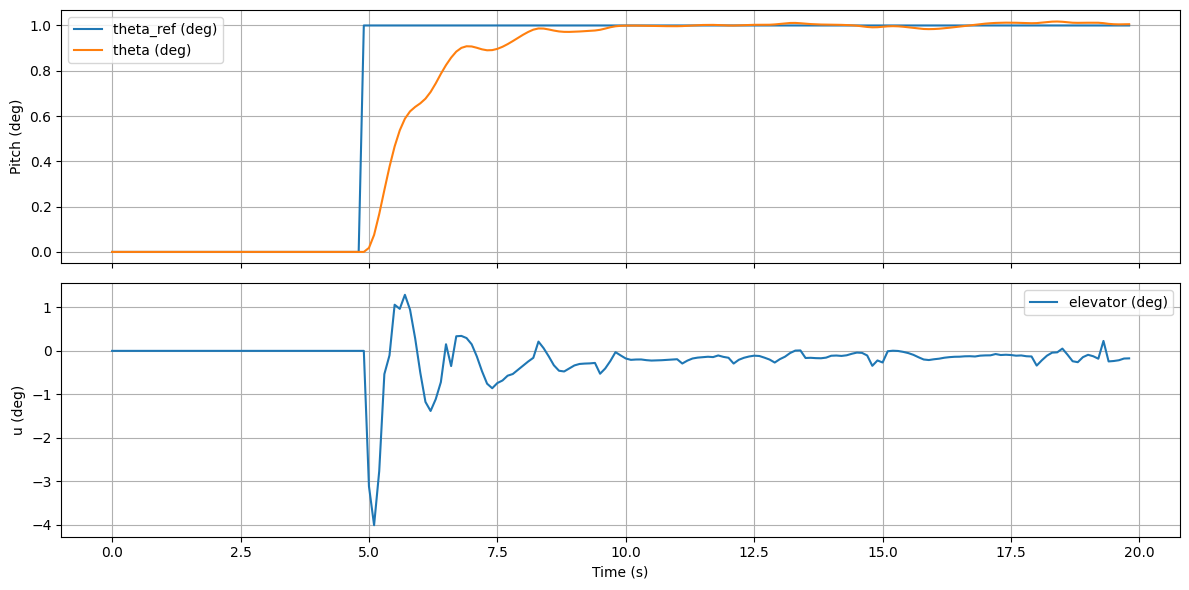


📊 ControlBenchmark metrics
        damping_degree: -0.011219894513487816
                   iae: 11.279732704162598
                   ise: 5.980903625488281
                  itae: 17.18000215291977
     maximum_deviation: 0.9999999403953552
     oscillation_count: 5
             overshoot: 1.7453374341130257
             peak_time: 2.0
     performance_index: 9.613429798185827
             rise_time: 1.6
         settling_time: 3.1
          static_error: -0.009175240993499756
    steady_state_value: 0.9999999403953552


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: B747 TorchMPCAgent (learned dynamics)           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                    

In [15]:
# 📈 Результаты: графики + step metrics + ControlBenchmark

hist_theta_deg = np.asarray(hist_theta_deg, dtype=np.float32)
hist_ref_deg = np.asarray(hist_ref_deg, dtype=np.float32)
hist_u_deg = np.asarray(hist_u_deg, dtype=np.float32)

t_plot = np.arange(hist_theta_deg.size, dtype=np.float32) * float(DT)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_plot, hist_ref_deg, label="theta_ref (deg)")
axes[0].plot(t_plot, hist_theta_deg, label="theta (deg)")
axes[0].set_ylabel("Pitch (deg)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_plot, hist_u_deg, label="elevator (deg)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("u (deg)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- ControlBenchmark ---
bench = ControlBenchmark()
signal_val = float(hist_ref_deg[0]) if hist_ref_deg.size else 0.0

metrics_bench = bench.becnchmarking_one_step(
    control_signal=hist_ref_deg,
    system_signal=hist_theta_deg,
    signal_val=signal_val,
    dt=float(DT),
)

print("\n" + "=" * 60)
print("📊 ControlBenchmark metrics")
print("=" * 60)
for k in sorted(metrics_bench.keys()):
    print(f"{k:>22s}: {metrics_bench[k]}")

print(
    "\n"
    + bench.generate_report(
        control_signal=hist_ref_deg,
        system_signal=hist_theta_deg,
        signal_val=signal_val,
        dt=float(DT),
        system_name="B747 TorchMPCAgent (learned dynamics)",
    )
)

SHOW_BENCHMARK_PLOT = True
if SHOW_BENCHMARK_PLOT and hist_ref_deg.size:
    ctrl_step, _ = find_step_function(hist_ref_deg, hist_theta_deg, signal_val=signal_val)
    tps_step = np.arange(ctrl_step.size, dtype=np.float32) * float(DT)
    bench.plot(
        control_signal=hist_ref_deg,
        system_signal=hist_theta_deg,
        signal_val=signal_val,
        dt=float(DT),
        tps=tps_step,
        title="B747 MPC Step Response (TorchMPCAgent)",
    )
